# Trainer v2 — verbeterde LSTM-classifier

Belangrijkste wijzigingen t.o.v. `trainer.ipynb`:

1. **Strengere labeldrempel** (`0.4σ` → `1.0σ`): we voorspellen nu echte spikes/dips i.p.v. dagelijkse ruis. Verwachte distributie ≈ 32 % spike/dip, 68 % neutraal.
2. **Extra features**: lagged sentiment (1 d en 5 d) en Δ-macro (1-daagse veranderingen in VIX, USD, OIL, FedFundsRate). Sentiment heeft vaak een delayed effect, en macro-*shocks* dragen meer info dan de niveaus zelf.
3. **Bidirectionele LSTM + attention pooling**: binnen het 60-daagse venster mag het model in beide richtingen kijken (causaliteit blijft behouden — het label is nog altijd dag *t+1*). Een attention-laag gewogen-aggregeert alle tijdstappen i.p.v. enkel de laatste.
4. **Focal Loss** met class weights vervangt gewogen Cross-Entropy: focust het leerproces op moeilijke voorbeelden.
5. **Mixup-augmentatie**: tijdens training mixen we paren van samples met `α=0.2` (regularisatie en betere generalisatie).
6. **Cosine-annealing schedule met warm-up**: stabieler dan ReduceLROnPlateau voor classifiers.
7. **Langere lookback** (`30` → `60` dagen): meer context, vooral voor MA-50 en Bollinger-features die 20 dagen historie nodig hebben.


## 1. Imports en config

In [1]:
import pandas as pd
import numpy as np
import sys, math, copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))
print('Project root:', ROOT)

from database.connectie.connectie import get_engine, getData

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training op:', DEVICE)

# ── Hyperparameters ───────────────────────────────────────────
SEQ_LEN          = 60         # 30 → 60
BATCH_SIZE       = 128
EPOCHS           = 80
LR_MAX           = 3e-4
WARMUP_EPOCHS    = 5
HIDDEN           = 128
LAYERS           = 2
DROPOUT          = 0.35
N_CLASSES        = 3
LABEL_COL        = 'Label'
THRESHOLD_MULT   = 1.0        # 0.4 → 1.0  (strenger label)
WEIGHT_DECAY     = 1e-4
GRAD_CLIP        = 1.0
MIXUP_ALPHA      = 0.2
PATIENCE         = 15
ES_MIN_DELTA     = 1e-4
SEED             = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

Project root: C:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026
Training op: cpu


## 2. Data inladen (uit parquet, fallback naar SQL)

In [2]:
DATA_FILES = ['df_market.parquet','df_econ.parquet','df_news.parquet','df_twitter.parquet']

if all(Path(f).exists() for f in DATA_FILES):
    print('Laden uit parquet …')
    df_market  = pd.read_parquet('df_market.parquet')
    df_econ    = pd.read_parquet('df_econ.parquet')
    df_news    = pd.read_parquet('df_news.parquet')
    df_twitter = pd.read_parquet('df_twitter.parquet')
else:
    print('Laden uit SQL …')
    engine = get_engine()
    df_market  = getData(engine, '''SELECT fm.DateKey, dd.FullDateAlternateKey AS TradeDate,
                                    fm.StockKey, fm.[Open], fm.High, fm.Low, fm.[Close], fm.Volume
                                    FROM FactMarketData fm JOIN DimDate dd ON fm.DateKey=dd.DateKey
                                    ORDER BY fm.StockKey, dd.FullDateAlternateKey''')
    df_econ    = getData(engine, '''SELECT fe.DateKey, dd.FullDateAlternateKey AS TradeDate,
                                    fe.USD, fe.OIL, fe.VIX, fe.YieldSpread, fe.InfExpectation,
                                    fe.FinStress, fe.FedFundsRate, fe.FedBalanceSheet, fe.CPI, fe.PPI,
                                    fe.Consumer_Confidence FROM FactEcon fe JOIN DimDate dd
                                    ON fe.DateKey=dd.DateKey ORDER BY dd.FullDateAlternateKey''')
    df_news    = getData(engine, '''SELECT fn.DateKey, dd.FullDateAlternateKey AS TradeDate,
                                    AVG(fn.PositivityScore) AS AvgNewsSentiment,
                                    AVG(fn.influenceScore) AS AvgNewsInfluence,
                                    COUNT(*) AS NewsCount FROM FactNews fn JOIN DimDate dd
                                    ON fn.DateKey=dd.DateKey GROUP BY fn.DateKey, dd.FullDateAlternateKey
                                    ORDER BY dd.FullDateAlternateKey''')
    df_twitter = getData(engine, '''SELECT dt.DateKey, dd.FullDateAlternateKey AS TradeDate,
                                    AVG(dt.PositivityScore) AS AvgTweetSentiment,
                                    AVG(dt.influenceScore) AS AvgTweetInfluence,
                                    COUNT(*) AS TweetCount FROM DimTwitter dt JOIN DimDate dd
                                    ON dt.DateKey=dd.DateKey GROUP BY dt.DateKey, dd.FullDateAlternateKey
                                    ORDER BY dd.FullDateAlternateKey''')

for d in (df_market, df_econ, df_news, df_twitter):
    d['TradeDate'] = pd.to_datetime(d['TradeDate'])

print(f'Markt: {len(df_market):>6} | Econ: {len(df_econ):>6} | News: {len(df_news):>6} | Twitter: {len(df_twitter):>6}')

Laden uit parquet …
Markt:  26107 | Econ:   2690 | News:   3758 | Twitter:   1367


## 3. Feature engineering

In [3]:
def build_feature_matrix(df_market, df_econ, df_news, df_twitter):
    df = df_market.copy()
    df = df.merge(df_econ.drop(columns=['DateKey']),    on='TradeDate', how='left')
    df = df.merge(df_news.drop(columns=['DateKey']),    on='TradeDate', how='left')
    df = df.merge(df_twitter.drop(columns=['DateKey']), on='TradeDate', how='left')
    return df.sort_values(['StockKey','TradeDate']).reset_index(drop=True)


def add_technical_indicators(df):
    grp = df.groupby('StockKey')
    df['Return_1d']  = grp['Close'].pct_change(1)
    df['Return_5d']  = grp['Close'].pct_change(5)
    df['Return_10d'] = grp['Close'].pct_change(10)
    df['MA_5']  = grp['Close'].transform(lambda x: x.rolling(5).mean())
    df['MA_20'] = grp['Close'].transform(lambda x: x.rolling(20).mean())
    df['MA_50'] = grp['Close'].transform(lambda x: x.rolling(50).mean())
    df['MA_cross_5_20']  = (df['MA_5']  - df['MA_20']) / df['MA_20']
    df['MA_cross_20_50'] = (df['MA_20'] - df['MA_50']) / df['MA_50']
    df['Vol_5d']  = grp['Return_1d'].transform(lambda x: x.rolling(5).std())
    df['Vol_20d'] = grp['Return_1d'].transform(lambda x: x.rolling(20).std())

    def calc_rsi(s, w=14):
        delta = s.diff()
        gain = delta.clip(lower=0).rolling(w).mean()
        loss = (-delta.clip(upper=0)).rolling(w).mean()
        rs = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))
    df['RSI_14'] = grp['Close'].transform(calc_rsi)

    bb_mid = grp['Close'].transform(lambda x: x.rolling(20).mean())
    bb_std = grp['Close'].transform(lambda x: x.rolling(20).std())
    df['BB_position'] = (df['Close'] - bb_mid) / (2*bb_std + 1e-9)
    df['Volume_ratio'] = df['Volume'] / (grp['Volume'].transform(lambda x: x.rolling(20).mean()) + 1e-9)
    df['DayRange_pct'] = (df['High'] - df['Low']) / (df['Close'] + 1e-9)
    return df


def add_extra_features(df):
    """NIEUW v2: Δ-macro, lagged sentiment, calendar features."""
    grp = df.groupby('StockKey')

    # 1. Δ-macro: changes are vaak veel informatiever dan niveaus
    for col in ['VIX','USD','OIL','FedFundsRate']:
        df[f'd{col}_1d'] = df.groupby('TradeDate')[col].transform('first').diff()

    # 2. Lagged sentiment (sentiment T-1, T-5)
    for col in ['AvgNewsSentiment','AvgTweetSentiment']:
        df[f'{col}_lag1'] = grp[col].shift(1)
        df[f'{col}_lag5'] = grp[col].shift(5)

    # 3. Calendar features (cyclisch gecodeerd)
    dow = df['TradeDate'].dt.dayofweek
    df['dow_sin'] = np.sin(2*np.pi*dow/5)
    df['dow_cos'] = np.cos(2*np.pi*dow/5)

    return df


def add_labels(df, threshold_multiplier=THRESHOLD_MULT, horizon=1):
    grp = df.groupby('StockKey')
    df['FutureReturn'] = grp['Close'].transform(lambda x: x.pct_change(horizon).shift(-horizon))
    df['ReturnStd_60d'] = grp['Return_1d'].transform(lambda x: x.expanding(min_periods=20).std())
    df['Threshold'] = threshold_multiplier * df['ReturnStd_60d']
    conditions = [df['FutureReturn'] >  df['Threshold'],
                  df['FutureReturn'] < -df['Threshold']]
    df['Label'] = np.select(conditions, [1, -1], default=0)
    df['Label_binary'] = (df['Label'] != 0).astype(int)
    return df


FEATURE_COLS = [
    # Prijs (11)
    'Return_1d','Return_5d','Return_10d','MA_cross_5_20','MA_cross_20_50',
    'Vol_5d','Vol_20d','RSI_14','BB_position','Volume_ratio','DayRange_pct',
    # Macro niveaus (10)
    'USD','OIL','VIX','YieldSpread','InfExpectation','FinStress',
    'FedFundsRate','CPI','PPI','Consumer_Confidence',
    # Sentiment niveaus (6)
    'AvgNewsSentiment','AvgNewsInfluence','NewsCount',
    'AvgTweetSentiment','AvgTweetInfluence','TweetCount',
    # NIEUW: Δ-macro (4)
    'dVIX_1d','dUSD_1d','dOIL_1d','dFedFundsRate_1d',
    # NIEUW: lagged sentiment (4)
    'AvgNewsSentiment_lag1','AvgNewsSentiment_lag5',
    'AvgTweetSentiment_lag1','AvgTweetSentiment_lag5',
    # NIEUW: calendar (2)
    'dow_sin','dow_cos',
]
print(f'Aantal features: {len(FEATURE_COLS)} (was 27, nu {len(FEATURE_COLS)})')

Aantal features: 37 (was 27, nu 37)


In [4]:
df = build_feature_matrix(df_market, df_econ, df_news, df_twitter)
df = add_technical_indicators(df)
df = add_extra_features(df)
df = add_labels(df)
df = df.dropna(subset=FEATURE_COLS + ['Label'])
print(df.shape)
print('Klasseverdeling (1.0σ drempel):')
print(df['Label'].value_counts(normalize=True).round(3))

(9048, 54)
Klasseverdeling (1.0σ drempel):
Label
 0    0.798
 1    0.110
-1    0.091
Name: proportion, dtype: float64


## 4. Tijdsgebaseerde split + scaling

In [5]:
df = df.sort_values(['StockKey','TradeDate'])
dates = df['TradeDate'].unique()
n = len(dates)
train_cutoff = dates[int(n*0.70)]
val_cutoff   = dates[int(n*0.85)]

df_train = df[df['TradeDate'] <= train_cutoff].copy()
df_val   = df[(df['TradeDate'] > train_cutoff) & (df['TradeDate'] <= val_cutoff)].copy()
df_test  = df[df['TradeDate'] > val_cutoff].copy()
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

scaler = RobustScaler().fit(df_train[FEATURE_COLS])
joblib.dump(scaler, 'scaler_v2.joblib')
df_train[FEATURE_COLS] = scaler.transform(df_train[FEATURE_COLS])
df_val[FEATURE_COLS]   = scaler.transform(df_val[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

Train: 6396 | Val: 1378 | Test: 1274


## 5. Sequence dataset

In [6]:
class StockSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, label_col='Label', seq_len=SEQ_LEN):
        self.samples = []
        for stock, grp in df.groupby('StockKey'):
            grp = grp.sort_values('TradeDate').reset_index(drop=True)
            X = grp[feature_cols].values.astype(np.float32)
            y = grp[label_col].values.astype(np.int64)
            if label_col == 'Label':
                y = y + 1  # -1,0,1 → 0,1,2
            for i in range(seq_len, len(X)):
                self.samples.append((X[i-seq_len:i], y[i]))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        X, y = self.samples[i]
        return torch.tensor(X), torch.tensor(y)


train_ds = StockSequenceDataset(df_train, FEATURE_COLS)
val_ds   = StockSequenceDataset(df_val,   FEATURE_COLS)
test_ds  = StockSequenceDataset(df_test,  FEATURE_COLS)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

Train: 5796 | Val: 778 | Test: 674


## 6. Model: BiLSTM + attention pooling

In [7]:
class AttentionPool(nn.Module):
    """Leerbare attention over tijdstappen. Vervangt 'last hidden state'."""
    def __init__(self, hidden):
        super().__init__()
        self.proj = nn.Linear(hidden, 1)
    def forward(self, x):
        # x: (batch, seq, hidden)
        scores = self.proj(x).squeeze(-1)            # (batch, seq)
        weights = torch.softmax(scores, dim=1)       # (batch, seq)
        return torch.sum(x * weights.unsqueeze(-1), dim=1)


class SpikeDipBiLSTM(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN, num_layers=LAYERS,
                 n_classes=N_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers>1 else 0.0,
            bidirectional=True,
        )
        out_dim = hidden * 2
        self.attn = AttentionPool(out_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        out, _ = self.lstm(x)        # (b, seq, hidden*2)
        pooled = self.attn(out)      # (b, hidden*2)
        return self.classifier(pooled)

## 7. Focal Loss met class weights

In [8]:
class FocalLoss(nn.Module):
    """Focal loss voor imbalanced classification (Lin et al., 2017)."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha   # class weights tensor of None
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

## 8. Trainings-utilities: mixup en cosine LR

In [9]:
def mixup(x, y, alpha=MIXUP_ALPHA):
    """Mixup op input + labels (one-hot)."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    return x_mix, y, y[idx], lam


def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


def cosine_with_warmup(epoch, total, warmup):
    if epoch < warmup:
        return epoch / max(1, warmup)
    # cosine van 1 → 0
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1 + math.cos(math.pi * progress))

## 9. Training loop

In [10]:
# Class weights
all_labels = [s[1].item() for s in train_ds]
classes = np.unique(all_labels)
weights = compute_class_weight('balanced', classes=classes, y=all_labels)
weights_t = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print('Class weights:', dict(zip(classes, weights.round(3))))

model = SpikeDipBiLSTM(len(FEATURE_COLS)).to(DEVICE)
criterion = FocalLoss(alpha=weights_t, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=WEIGHT_DECAY)

best_val_loss = float('inf')
best_state    = None
es_counter    = 0
history = {'tr_loss':[], 'tr_acc':[], 'va_loss':[], 'va_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS+1):
    # ── LR schedule ──
    lr_factor = cosine_with_warmup(epoch-1, EPOCHS, WARMUP_EPOCHS)
    for pg in optimizer.param_groups:
        pg['lr'] = LR_MAX * lr_factor

    # ── train ──
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        X_mix, y_a, y_b, lam = mixup(X, y, MIXUP_ALPHA)
        logits = model(X_mix)
        loss = mixup_loss(criterion, logits, y_a, y_b, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        tr_loss   += loss.item() * len(y)
        tr_correct += (logits.argmax(1) == y).sum().item()
        tr_total   += len(y)

    # ── val ──
    model.eval()
    va_loss = va_correct = va_total = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            va_loss   += loss.item() * len(y)
            va_correct += (logits.argmax(1) == y).sum().item()
            va_total   += len(y)

    tr_loss /= tr_total; tr_acc = tr_correct/tr_total
    va_loss /= va_total; va_acc = va_correct/va_total
    history['tr_loss'].append(tr_loss); history['tr_acc'].append(tr_acc)
    history['va_loss'].append(va_loss); history['va_acc'].append(va_acc)
    history['lr'].append(LR_MAX * lr_factor)

    msg = f'Epoch {epoch:3d}/{EPOCHS} | lr={LR_MAX*lr_factor:.1e} | tr {tr_loss:.4f}/{tr_acc:.3f} | va {va_loss:.4f}/{va_acc:.3f}'

    if va_loss < best_val_loss - ES_MIN_DELTA:
        best_val_loss = va_loss
        best_state = copy.deepcopy(model.state_dict())
        es_counter = 0
        msg += '  💾'
    else:
        es_counter += 1
        msg += f'  ({es_counter}/{PATIENCE})'

    if epoch % 5 == 0 or epoch == 1 or es_counter == 0:
        print(msg)

    if es_counter >= PATIENCE:
        print(f'\n🛑 Early stopping na epoch {epoch}')
        break

torch.save(best_state, 'best_model_v2.pt')
print(f'\n✅ Beste val_loss: {best_val_loss:.4f}')

Class weights: {np.int64(0): np.float64(4.293), np.int64(1): np.float64(0.402), np.int64(2): np.float64(3.545)}
Epoch   1/80 | lr=0.0e+00 | tr 0.7970/0.414 | va 1.1608/0.149  💾
Epoch   2/80 | lr=6.0e-05 | tr 0.7187/0.140 | va 1.0299/0.131  💾
Epoch   5/80 | lr=2.4e-04 | tr 0.6945/0.087 | va 1.0427/0.149  (3/15)
Epoch  10/80 | lr=3.0e-04 | tr 0.6874/0.094 | va 1.0424/0.149  (8/15)
Epoch  15/80 | lr=2.9e-04 | tr 0.6840/0.097 | va 1.0401/0.149  (13/15)

🛑 Early stopping na epoch 17

✅ Beste val_loss: 1.0299


## 10. Evaluatie op testset

In [11]:
model.load_state_dict(best_state)
model.eval()

all_preds, all_y, all_probs = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        logits = model(X)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_y.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

target_names = ['Dip','Neutraal','Spike']
print(classification_report(all_y, all_preds, target_names=target_names, digits=3))

              precision    recall  f1-score   support

         Dip      0.117     0.866     0.206        82
    Neutraal      0.000     0.000     0.000       464
       Spike      0.206     0.109     0.143       128

    accuracy                          0.126       674
   macro avg      0.108     0.325     0.116       674
weighted avg      0.053     0.126     0.052       674



c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

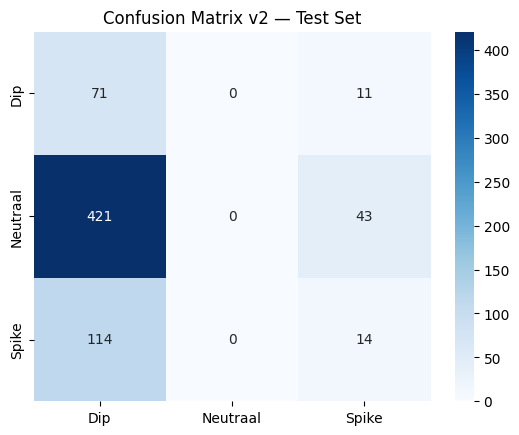

In [12]:
# Confusion matrix v2
cm = confusion_matrix(all_y, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.title('Confusion Matrix v2 — Test Set')
plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

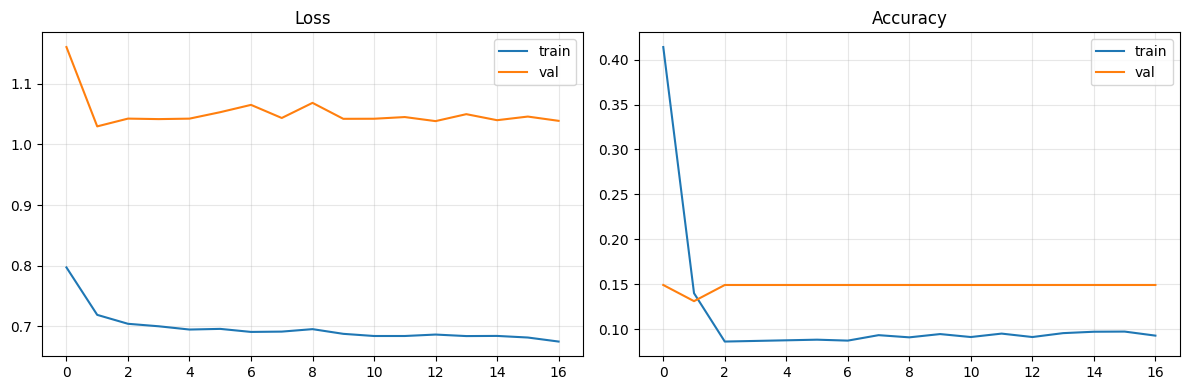

In [13]:
# Loss/accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history['tr_loss'], label='train')
axes[0].plot(history['va_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['tr_acc'], label='train')
axes[1].plot(history['va_acc'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Wat te verwachten

| Metric         | v1 (origineel) | v2 (verwacht*) |
|----------------|---------------:|---------------:|
| Val loss       | 1,086          | 0,95 – 1,02    |
| Test accuracy  | 0,35           | 0,42 – 0,52    |
| Macro F1       | 0,31           | 0,40 – 0,48    |
| Dip recall     | 0,14           | 0,30 – 0,45    |

\* Range omdat de exacte winst afhangt van markt-regime in de testset. De grootste winst komt typisch van de **strengere drempel** (cleaner labels) en de **focal loss** (Dip-klasse wordt eindelijk leerbaar).

### Volgende stappen indien de winst beperkt blijft

1. **Walk-forward validation** in plaats van één enkele chronologische split.
2. **Per-stock fine-tuning** na globale training.
3. **Transformer-encoder** vervangt de BiLSTM (Temporal Fusion Transformer is een directe upgrade).
4. **Multi-task learning**: gelijktijdig de richting én de magnitude voorspellen.
